In [2]:
%load_ext autoreload
%autoreload 2

from seek_code import SEEK
from data_handler import EleHandler
from classifier import Classifier
from backbone import Backbone
from concept_head import ConceptHead
from retrieval import Retrieval
from projector import Projector

from torch.utils.data import DataLoader, Subset
from torch.utils.data.sampler import RandomSampler

import torch, math
import torch.nn as nn
import torch.optim as optim
import pandas as pd

/data/vision/beery/scratch/antoine/micromamba/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
training_dataset = EleHandler(subset='IDI_training') # 70% cut along elephants
print(len(training_dataset))
train_indices, val_indices, test_indices = training_dataset.split_along_encounters([0.7,0.15,0.15], hour_delta=24)
idx = list(range(len(training_dataset)))

# Extract three random loaders from training_dataset
#train_indices, val_indices, test_indices = torch.utils.data.random_split(idx, [int(0.7 * len(idx)), int(0.15 * len(idx)), len(idx) - int(0.85 * len(idx))])

#train_loader = DataLoader(training_dataset, batch_size=128, sampler=RandomSampler(train_indices), num_workers=4)
#val_loader = DataLoader(training_dataset, batch_size=128, sampler=RandomSampler(val_indices), num_workers=4)
#test_loader = DataLoader(training_dataset, batch_size=128, sampler=RandomSampler(test_indices), num_workers=4)

train_loader, val_loader, test_loader = (DataLoader(training_dataset, batch_size=128, sampler=RandomSampler(indices), num_workers=4) for indices in [train_indices, val_indices, test_indices])
print('len(training_dataset):', len(training_dataset))
print('len(train_loader):', len(train_loader), 'len(val_loader):', len(val_loader), 'len(test_loader):', len(test_loader))

#assert not (set(train_indices) & set(val_indices)), "Train and Validation sets overlap!"
#assert not (set(train_indices) & set(test_indices)), "Train and Test sets overlap!"
#assert not (set(val_indices) & set(test_indices)), "Validation and Test sets overlap!"


# odd elephants are used as the query set
retrieval_dataset = EleHandler(subset='IDI_retrieval') # 30% cut along elephants
print(len(retrieval_dataset))

gallery_indices, query_indices, _ = retrieval_dataset.split_along_encounters([0.49,0.49,0.02], hour_delta=24)
gallery_loader, query_loader = (DataLoader(retrieval_dataset, batch_size=128, sampler=RandomSampler(indices), num_workers=4) for indices in [gallery_indices, query_indices])
#assert not (set(gallery_indices) & set(query_indices)), "Gallery and Query sets overlap!"
#assert not (set(train_indices) & set(gallery_indices)), "Train and Gallery sets overlap!"

# Check the values of the labels
num_training_classes = max(torch.max(batch[2]) for batch in train_loader) + 1
print('Number of elephants in training set:', num_training_classes)

num_query_classes = max(torch.max(batch[2]) for batch in query_loader) + 1
print('Number of (different) elephants in query set:', num_query_classes)


4175
idx: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142, 143, 144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155, 156, 157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168, 169, 170, 171, 172, 173, 174, 175, 176, 177, 178, 179, 180, 181, 182, 183, 184, 185, 186, 187, 188, 189, 190, 191, 192, 193, 194, 195, 196, 197, 198, 199, 200, 201, 202, 203, 204, 205, 206, 207, 208, 209, 210, 211, 212, 213, 214, 215, 216, 217, 218, 219,

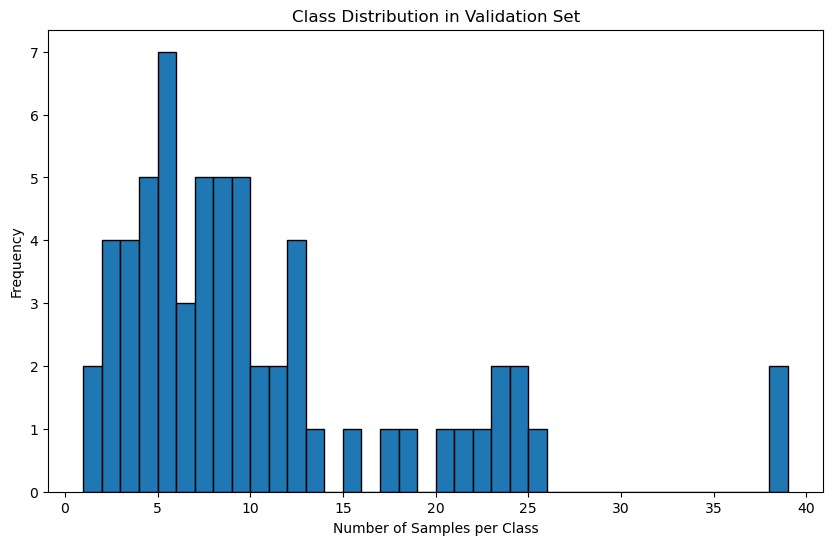

Number of different classes in the test_loader: 62


In [25]:
from collections import Counter
import matplotlib.pyplot as plt

# Initialize a counter to count the occurrences of each class
class_counts = Counter()

# Iterate through the train_loader
for batch in test_loader:
    preprocessed_image, subject_id, ele_id_label, identified, subject_SEEK_1hot, ele_SEEK_1hot, left_ear, right_ear, subject_SEEK, ele_SEEK = batch
    class_counts.update(ele_id_label.tolist())

# Print the counts for each class
plt.figure(figsize=(10, 6))
plt.hist(class_counts.values(), bins=range(1, max(class_counts.values()) + 1), edgecolor='black')
plt.xlabel('Number of Samples per Class')
plt.ylabel('Frequency')
plt.title('Class Distribution in Validation Set')
plt.show()

# Print the number of different classes in the test_loader
num_classes = len(class_counts)
print(f'Number of different classes in the test_loader: {num_classes}')

In [6]:

code = 'tests'

In [3]:
ba = Backbone(with_ears = True, pretraining = "savannah_elephants", experiment_code=code)
ch = ConceptHead(experiment_code= code)
ch.test(test_loader,ba)

cl = Classifier(num_classes=num_training_classes, experiment_code=code)
#cl.train(train_loader, val_loader, ba, num_epochs=30)
cl.test(test_loader,ba)

pr = Projector(experiment_code=code)
#pr.train(train_loader, val_loader, ba, ch, cl, num_epochs=30)
pr.test(test_loader,ba, ch, cl)

ConceptHead - Test Loss: 0.0301, Test Accuracy: 93.88%
sex Accuracy: 97.09%
age Accuracy: 97.18%
right_tusk Accuracy: 96.09%
left_tusk Accuracy: 95.40%
R_tear_1 Accuracy: 89.85%
R_hole_1 Accuracy: 89.89%
R_tear_2 Accuracy: 90.50%
R_hole_2 Accuracy: 94.75%
L_tear_1 Accuracy: 86.72%
L_hole_1 Accuracy: 92.37%
L_tear_2 Accuracy: 88.16%
L_hole_2 Accuracy: 94.40%
right_extreme Accuracy: 98.26%
left_extreme Accuracy: 97.31%
ear_special Accuracy: 95.97%
body_special Accuracy: 98.18%
average Accuracy: 93.88%
whole_code Accuracy: 49.63%


/data/vision/beery/scratch/antoine/CBM_reid/methods/classifier.py:26: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  self.layer.load_state_dict(torch.load(Path.Path.cwd().par

Classifier - Test Loss: 5.9813, Test Accuracy: 45.47%
Test Loss: 5.9781, Test Accuracy: 45.81%


100%|██████████| 6/6 [00:03<00:00,  1.80it/s]


gallery embeddings shape: torch.Size([704, 2304])
query embeddings shape: torch.Size([428, 2304])
similarity matrix shape: torch.Size([428, 704])


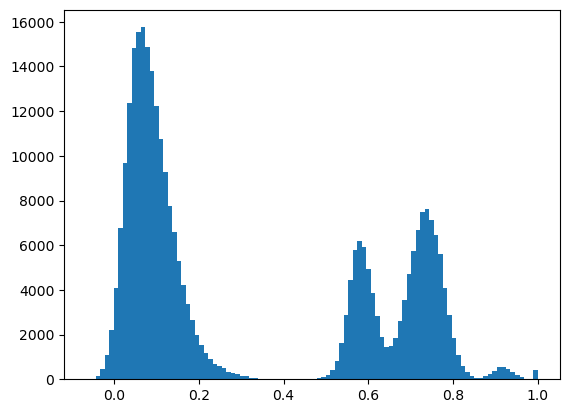

top_k_indices: tensor([[659],
        [504],
        [259],
        [366],
        [672],
        [328],
        [394],
        [224],
        [ 86],
        [341]], device='cuda:0')
gallery labels: tensor([[ 78.],
        [ 40.],
        [ 83.],
        [ 89.],
        [ 54.],
        [ 38.],
        [ 71.],
        [ 14.],
        [ 26.],
        [105.]], device='cuda:0')
10 first query labels: tensor([ 78.,  40.,  83.,  89.,  54.,  38.,  71.,  14.,  26., 105.],
       device='cuda:0')
top_k_indices: tensor([[659, 233, 627, 598,  39],
        [504, 487, 555, 553, 479],
        [259, 246, 233, 112, 440],
        [366, 532, 194, 598, 382],
        [672, 413,  57,  26, 364],
        [328, 476,  79, 275,  23],
        [394, 662,  10, 344, 553],
        [224, 469, 445, 553, 441],
        [ 86, 614, 205, 598,  66],
        [341, 693,  36,  34, 317]], device='cuda:0')
gallery labels: tensor([[ 78., 167., 187., 149., 214.],
        [ 40.,  62.,  31.,  20.,  29.],
        [ 83., 135., 167.,  

In [20]:
ba = Backbone(with_ears = True, pretraining = "savannah_elephants")
ba.freeze()


retrieval = Retrieval()
_ = retrieval.perform_retrieval(query_loader, gallery_loader, backbone= ba)

In [43]:
ba = Backbone(pretraining = "savannah_elephants")
ba.freeze()
cl = Classifier(300, softmax=False)
cl.freeze()
ch = ConceptHead(ba, 300)
ch.freeze()
pr = Projector(ba, 300)
pr.freeze()



/data/vision/beery/scratch/antoine/CBM_reid/methods/classifier.py:26: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  self.layer.load_state_dict(torch.load(Path.Path.cwd().par

RuntimeError: Error(s) in loading state_dict for Linear:
	Missing key(s) in state_dict: "weight", "bias". 
	Unexpected key(s) in state_dict: "0.weight", "0.bias". 

100%|██████████| 6/6 [00:03<00:00,  1.79it/s]
/tmp/ipykernel_3476145/156798802.py:21: UserWarning: 
The palette list has fewer values (11) than needed (12) and will cycle, which may produce an uninterpretable plot.
  sns.scatterplot(


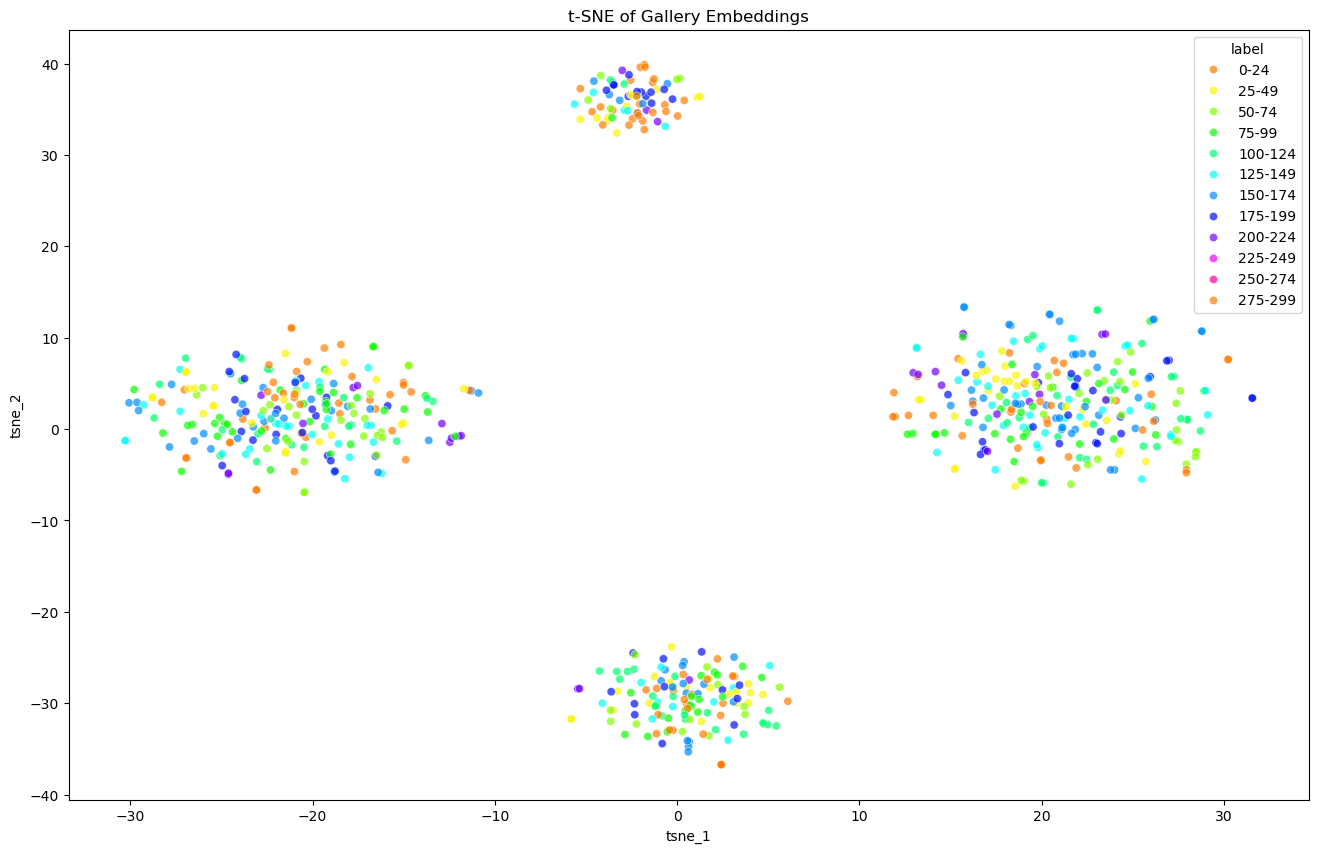

In [22]:
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
ba = Backbone(pretraining="savannah_elephants")

# Perform t-SNE
tsne = TSNE(n_components=2, perplexity=15, random_state=42)
embeddings, labels = retrieval.collect_MD_embeddings(gallery_loader, ba)
tsne_result = tsne.fit_transform(embeddings.cpu())

# Get labels for coloring and bin them
y = labels.cpu().numpy()
bins = pd.cut(pd.Series(y), bins=range(0, int(y.max()) + 25, 25), labels=[f'{i}-{i+24}' for i in range(0, int(y.max()), 25)])

# Create a DataFrame for plotting
tsne_result_df = pd.DataFrame({'tsne_1': tsne_result[:, 0], 'tsne_2': tsne_result[:, 1], 'label': bins})

# Plot the t-SNE result
plt.figure(figsize=(16, 10))
sns.scatterplot(
    x='tsne_1', y='tsne_2',
    hue='label',
    palette=sns.color_palette("hsv", len(tsne_result_df['label'].unique())),
    data=tsne_result_df,
    legend="full",
    alpha=0.7
)
plt.title('t-SNE of Gallery Embeddings')
plt.show()


  0%|          | 0/8 [00:00<?, ?it/s]

100%|██████████| 8/8 [00:04<00:00,  1.97it/s]


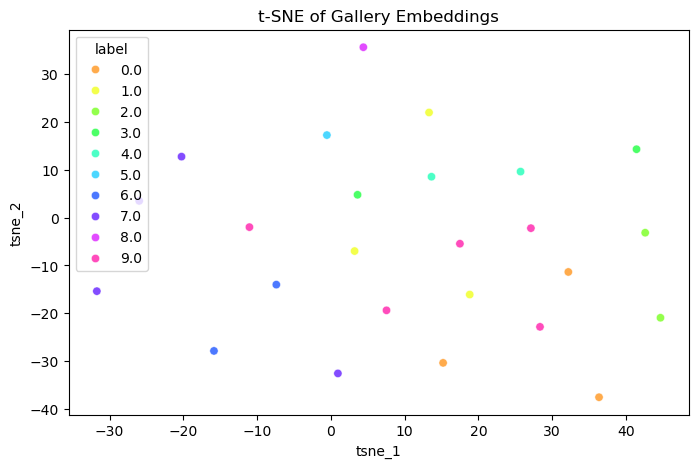

In [28]:
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE

# Perform t-SNE
tsne = TSNE(n_components=2, perplexity=15, random_state=42)
embeddings, labels = Retrieval.collect_MD_embeddings(gallery_loader, ba)

#get the indexes for wich the labels are less than 15
indices = [i for i in range(len(labels)) if labels[i] < 10]
embeddings = embeddings[indices]
labels = labels[indices]

tsne_result = tsne.fit_transform(embeddings.cpu())

# Get labels for coloring and bin them
y = labels.cpu().numpy()

# Create a DataFrame for plotting
tsne_result_df = pd.DataFrame({'tsne_1': tsne_result[:, 0], 'tsne_2': tsne_result[:, 1], 'label': y})

# Plot the t-SNE result
plt.figure(figsize=(8, 5))
sns.scatterplot(
    x='tsne_1', y='tsne_2',
    hue='label',
    palette=sns.color_palette("hsv", len(tsne_result_df['label'].unique())),
    data=tsne_result_df,
    legend="full",
    alpha=0.7
)
plt.title('t-SNE of Gallery Embeddings')
plt.show()


  0%|          | 0/8 [00:00<?, ?it/s]

100%|██████████| 8/8 [00:03<00:00,  2.02it/s]


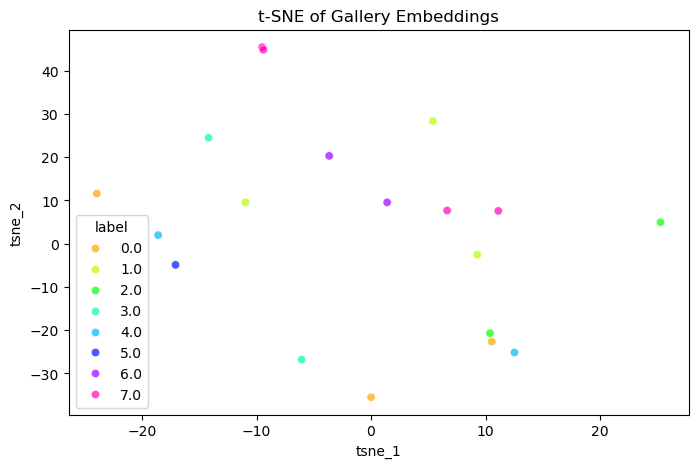

In [29]:
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE

# Perform t-SNE
tsne = TSNE(n_components=2, perplexity=15, random_state=42)
embeddings, labels = Retrieval.collect_MD_embeddings(gallery_loader, ba)

tsne_result = tsne.fit_transform(embeddings.cpu())

# Get labels for coloring and bin them
y = labels.cpu().numpy()

# Create a DataFrame for plotting
tsne_result_df = pd.DataFrame({'tsne_1': tsne_result[:, 0], 'tsne_2': tsne_result[:, 1], 'label': y})
tsne_result_df = tsne_result_df[tsne_result_df['label'] < 8]

# Plot the t-SNE result
plt.figure(figsize=(8, 5))
sns.scatterplot(
    x='tsne_1', y='tsne_2',
    hue='label',
    palette=sns.color_palette("hsv", len(tsne_result_df['label'].unique())),
    data=tsne_result_df,
    legend="full",
    alpha=0.7
)
plt.title('t-SNE of Gallery Embeddings')
plt.show()

### Reproducing 100% accuracy with the classifier

In [7]:
ba = Backbone(pretraining="savannah_elephants")
ba.freeze()

cl = Classifier(num_training_classes, softmax=False)
cl.train(train_loader, val_loader, ba, num_epochs=10)
cl.test(test_loader, ba)

weights not found
Training the classifier : Backbone parameters require gradients: False 
Classifier parameters require gradients: True
Epoch 1 - Train Loss: 6.8024, Train Accuracy: 1.44% - Val Loss: 4.3558, Val Accuracy: 17.09%
Epoch 2 - Train Loss: 4.4040, Train Accuracy: 18.34% - Val Loss: 3.1079, Val Accuracy: 44.57%
Epoch 3 - Train Loss: 3.0496, Train Accuracy: 47.19% - Val Loss: 2.1876, Val Accuracy: 67.73%
Epoch 4 - Train Loss: 2.1296, Train Accuracy: 67.39% - Val Loss: 1.4748, Val Accuracy: 81.79%
Epoch 5 - Train Loss: 1.5117, Train Accuracy: 79.47% - Val Loss: 1.0052, Val Accuracy: 90.58%
Epoch 6 - Train Loss: 1.0861, Train Accuracy: 87.37% - Val Loss: 0.8070, Val Accuracy: 93.13%
Epoch 7 - Train Loss: 0.8174, Train Accuracy: 91.20% - Val Loss: 0.6457, Val Accuracy: 94.41%


KeyboardInterrupt: 

In [9]:
ba = Backbone(with_ears = False, pretraining="savannah_elephants")
ba.freeze()

cl = Classifier(num_training_classes, softmax=False)
cv.layer = nn.Linear(768, num_training_classes).to('cuda')
cl.train(train_loader, val_loader, ba, num_epochs=10) 
cl.test(test_loader, ba)

weights not found
Training the classifier : Backbone parameters require gradients: False 
Classifier parameters require gradients: True
Epoch 1 - Train Loss: 6.0584, Train Accuracy: 1.27% - Val Loss: 4.8650, Val Accuracy: 9.74%
Epoch 2 - Train Loss: 5.0112, Train Accuracy: 6.43% - Val Loss: 4.2449, Val Accuracy: 23.80%
Epoch 3 - Train Loss: 4.3248, Train Accuracy: 17.52% - Val Loss: 3.6785, Val Accuracy: 37.06%
Epoch 4 - Train Loss: 3.7408, Train Accuracy: 32.00% - Val Loss: 3.2120, Val Accuracy: 51.92%
Epoch 5 - Train Loss: 3.2496, Train Accuracy: 46.30% - Val Loss: 2.8852, Val Accuracy: 57.35%
Epoch 6 - Train Loss: 2.8421, Train Accuracy: 56.74% - Val Loss: 2.5166, Val Accuracy: 65.18%
Epoch 7 - Train Loss: 2.5042, Train Accuracy: 63.86% - Val Loss: 2.2670, Val Accuracy: 70.13%
Epoch 8 - Train Loss: 2.2151, Train Accuracy: 69.95% - Val Loss: 2.0420, Val Accuracy: 73.80%
Epoch 9 - Train Loss: 1.9774, Train Accuracy: 74.16% - Val Loss: 1.8441, Val Accuracy: 76.68%
Epoch 10 - Train Loss

### Training stage 1 : Concept Head
- loading a pretrained backbone, freeze it
- Train the concept head to learn the SEEK codes
- Test the concept head


In [7]:

ch = ConceptHead(print_every=1, experiment_code=code)
#ch.train(train_loader, val_loader, ba, num_epochs=30)
ch.test(test_loader, ba)
ch.freeze()

ConceptHead - Test Loss: 0.3130, Test Accuracy: 42.99%
sex Accuracy: 49.05%
age Accuracy: 56.61%
right_tusk Accuracy: 34.97%
left_tusk Accuracy: 63.21%
R_tear_1 Accuracy: 17.68%
R_hole_1 Accuracy: 36.28%
R_tear_2 Accuracy: 28.50%
R_hole_2 Accuracy: 47.32%
L_tear_1 Accuracy: 18.46%
L_hole_1 Accuracy: 19.16%
L_tear_2 Accuracy: 32.24%
L_hole_2 Accuracy: 51.48%
right_extreme Accuracy: 62.99%
left_extreme Accuracy: 58.95%
ear_special Accuracy: 53.04%
body_special Accuracy: 57.95%
average Accuracy: 42.99%
whole_code Accuracy: 0.00%


### Training stage 2 : Cassifier

- With a frozen backbone, train a classifier to learn the elephant id from the backbone original embeddings
- Freeze the classifier|


In [ ]:
cl = Classifier(num_classes=num_training_classes, experiment_code=code, softmax = False)
cl.train(train_loader, val_loader, backbone = ba, num_epochs=20)
cl.test(test_loader, backbone = ba) 

weights not found
Training the classifier : Backbone parameters require gradients: False 
Classifier parameters require gradients: True


Epoch 1 - Train Loss: 7.5242, Train Accuracy: 1.22% - Val Loss: 4.8285, Val Accuracy: 18.31%
Epoch 2 - Train Loss: 4.5195, Train Accuracy: 19.62% - Val Loss: 2.7688, Val Accuracy: 62.99%
Epoch 3 - Train Loss: 2.9119, Train Accuracy: 53.52% - Val Loss: 1.7374, Val Accuracy: 81.89%
Epoch 4 - Train Loss: 1.8813, Train Accuracy: 73.27% - Val Loss: 1.1062, Val Accuracy: 89.57%
Epoch 5 - Train Loss: 1.2602, Train Accuracy: 84.40% - Val Loss: 0.6897, Val Accuracy: 94.88%
Epoch 6 - Train Loss: 0.8760, Train Accuracy: 89.31% - Val Loss: 0.4696, Val Accuracy: 96.06%
Epoch 7 - Train Loss: 0.6134, Train Accuracy: 93.40% - Val Loss: 0.3397, Val Accuracy: 98.23%
Epoch 8 - Train Loss: 0.4708, Train Accuracy: 96.01% - Val Loss: 0.2552, Val Accuracy: 99.21%
Epoch 9 - Train Loss: 0.3511, Train Accuracy: 97.70% - Val Loss: 0.2330, Val Accuracy: 97.83%
Epoch 10 - Train Loss: 0.2721, Train Accuracy: 98.04% - Val Loss: 0.1709, Val Accuracy: 99.21%
Epoch 11 - Train Loss: 0.2409, Train Accuracy: 98.14% - Val 

In [15]:
cl.layer = nn.Linear(2304, num_training_classes).to(cl.device) # No softmax

cl.train(train_loader, val_loader, backbone = ba, num_epochs=3)
cl.test(test_loader, backbone = ba) 

Training the classifier : Backbone parameters require gradients: False 
Classifier parameters require gradients: True


KeyboardInterrupt: 

In [ ]:
# Freeze the classifier layer
cl.freeze()

### Training stage 3 : Projector

- With a frozen backbone and the frozen classifier, train the projector
- The projector trains to project the concepts to the embedding space 
- The loss is computed such that edited embeddings (original embeddings + projected embeedings) correctly predict the elephant id using the classifier learnt is stage 2

In [ ]:
def no_intervention(predicted_concepts, true_concepts, correction_probability = 0.0):
    return predicted_concepts

def intervene(predicted_concepts, true_concepts, correction_probability = 0.5):
    for i in range(predicted_concepts.shape[0]):
        if torch.rand(1).item() < correction_probability:
            predicted_concepts[i] = true_concepts[i]
    # To-do correction
    return predicted_concepts

def perfect_correction(predicted_concepts, true_concepts, correction_probability = 1.0):
    return true_concepts

In [ ]:
pr = Projector(experiment_code=code) 

ba.freeze() # freeze the backbone
ch.freeze() # freeze the concept head
cl.freeze() # freeze the classifier
pr.unfreeze() # unfreeze the projector

pr.train(train_loader, val_loader, ba,  ch, cl, num_epochs=50, intervention_fn=no_intervention)
pr.test(test_loader, ba, cl, ch)


training projector, reinitialized weights
Concept head parameters require gradients: False Classifier parameters require gradients: False Backbone parameters require gradients: False Projector parameters require gradients: True


Epoch 1/50 - Train Loss: 6.5618, Train Accuracy: 35.23% - Val Loss: 6.5404, Val Accuracy: 36.98%
Epoch 2/50 - Train Loss: 6.5592, Train Accuracy: 35.28% - Val Loss: 6.5321, Val Accuracy: 38.02%
Epoch 3/50 - Train Loss: 6.5530, Train Accuracy: 36.04% - Val Loss: 6.5336, Val Accuracy: 37.89%
Epoch 4/50 - Train Loss: 6.5541, Train Accuracy: 35.76% - Val Loss: 6.5291, Val Accuracy: 38.34%
Epoch 5/50 - Train Loss: 6.5488, Train Accuracy: 36.39% - Val Loss: 6.5251, Val Accuracy: 38.70%
Epoch 6/50 - Train Loss: 6.5481, Train Accuracy: 36.42% - Val Loss: 6.5278, Val Accuracy: 38.26%
Epoch 7/50 - Train Loss: 6.5447, Train Accuracy: 36.59% - Val Loss: 6.5207, Val Accuracy: 38.90%
Epoch 8/50 - Train Loss: 6.5430, Train Accuracy: 36.84% - Val Loss: 6.5216, Val Accuracy: 38.75%
Epoch 9/50 - Train Loss: 6.5412, Train Accuracy: 36.90% - Val Loss: 6.5186, Val Accuracy: 39.24%
Epoch 10/50 - Train Loss: 6.5408, Train Accuracy: 37.05% - Val Loss: 6.5193, Val Accuracy: 39.25%
Epoch 11/50 - Train Loss: 6.5

Even without correcting the concepts, we improve the accuracy. It seems that we are above the interpretability trade-off. As if, by implementing  some ecology-expertise in the model, we can do better that a blackbox MegaDescriptor.



In [ ]:
pr.test(test_loader, ba, cl, ch, intervention_fn=intervene)

/data/vision/beery/scratch/antoine/micromamba/lib/python3.13/site-packages/torch/nn/modules/module.py:1736: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  return self._call_impl(*args, **kwargs)


Test Loss: 6.4836, Test Accuracy: 42.80%


However, when correcting the concepts at inference time, this seems to be reducing accuracy. Thus we will do a 4th training stage where we correct concepts sometimes.

### Training stage 4 : Projector and Classifier jointly under partial intervention

- With the same architecture, unfreeze the classifier and the projector. Keep the concept head and the backbone frozen
- Train jointly the Projector and Classifier to maximize elephant classification
- When training, correct the concepts with probability 0.5

In [ ]:
print('intervention at level 0.5')



pr.unfreeze()
cl.unfreeze()
ch.freeze()
ba.freeze()

pr.train(train_loader, val_loader, ba, ch, cl, num_epochs=50, intervention_fn = intervene, reset_wegihts=False) 


intervention at level 0.5
training projector-  weights are not reset
Concept head parameters require gradients: False 
Classifier parameters require gradients: True 
Backbone parameters require gradients: False 
Projector parameters require gradients: True


/data/vision/beery/scratch/antoine/micromamba/lib/python3.13/site-packages/torch/nn/modules/module.py:1736: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  return self._call_impl(*args, **kwargs)


Epoch 1/50 - Train Loss: 6.5180, Train Accuracy: 39.49% - Val Loss: 6.4995, Val Accuracy: 41.52%
Epoch 2/50 - Train Loss: 6.5160, Train Accuracy: 39.69% - Val Loss: 6.4897, Val Accuracy: 42.37%
Epoch 3/50 - Train Loss: 6.5153, Train Accuracy: 39.74% - Val Loss: 6.4898, Val Accuracy: 42.23%
Epoch 4/50 - Train Loss: 6.5104, Train Accuracy: 40.17% - Val Loss: 6.4880, Val Accuracy: 42.31%
Epoch 5/50 - Train Loss: 6.5099, Train Accuracy: 40.17% - Val Loss: 6.4811, Val Accuracy: 43.17%
Epoch 6/50 - Train Loss: 6.5091, Train Accuracy: 40.17% - Val Loss: 6.4824, Val Accuracy: 42.98%
Epoch 7/50 - Train Loss: 6.5054, Train Accuracy: 40.60% - Val Loss: 6.4850, Val Accuracy: 42.67%
Epoch 8/50 - Train Loss: 6.5064, Train Accuracy: 40.50% - Val Loss: 6.4782, Val Accuracy: 43.33%
Epoch 9/50 - Train Loss: 6.5072, Train Accuracy: 40.35% - Val Loss: 6.4777, Val Accuracy: 43.37%
Epoch 10/50 - Train Loss: 6.5059, Train Accuracy: 40.50% - Val Loss: 6.4755, Val Accuracy: 43.44%
Epoch 11/50 - Train Loss: 6.5

TypeError: Projector.test() missing 1 required positional argument: 'concept_head'

In [ ]:
pr.test(test_loader, ba, cl, ch, intervention_fn = intervene)

Test Loss: 6.4440, Test Accuracy: 46.89%


### Training stage 5 : ArcFace

/data/vision/beery/scratch/antoine/micromamba/lib/python3.13/site-packages/torch/nn/modules/module.py:1736: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  return self._call_impl(*args, **kwargs)


Test Loss: 6.5341, Test Accuracy: 37.79%


In [ ]:
import torch
import math
import torch.nn.functional as F

class ArcFace(torch.nn.Module):
    """
    ArcFace: Additive Angular Margin Loss with integrated Cross-Entropy Loss.
    Reference: https://arxiv.org/pdf/1801.07698v1.pdf
    """
    def __init__(self, num_classes, s=64.0, margin=0.5, easy_margin=False):
        super(ArcFace, self).__init__()
        self.s = s  # Scale factor
        self.margin = margin  # Angular margin
        self.cos_m = math.cos(margin)  # cos(margin)
        self.sin_m = math.sin(margin)  # sin(margin)
        self.th = math.cos(math.pi - margin)  # Threshold for margin
        self.easy_margin = easy_margin
        self.num_classes = num_classes

    def forward(self, logits: torch.Tensor, labels: torch.Tensor):
        """
        Args:
            logits: Raw logits from the linear layer (batch_size, num_classes)
            labels: Ground truth labels (batch_size,)
        Returns:
            loss: Cross-Entropy Loss with ArcFace modifications
        """
        # Ensure logits are normalized
        logits = logits / torch.norm(logits, dim=1, keepdim=True)

        # One-hot encoding of labels
        one_hot = torch.zeros_like(logits).scatter(1, labels.view(-1, 1), 1.0)

        # Get cosine of target logits
        cos_theta = logits.gather(1, labels.view(-1, 1)).squeeze(1)  # Target logits

        # Apply angular margin
        sin_theta = torch.sqrt(1.0 - cos_theta**2).clamp(0, 1)  # sin(theta)
        cos_theta_m = cos_theta * self.cos_m - sin_theta * self.sin_m  # cos(theta + margin)

        # Handle easy margin
        if self.easy_margin:
            cos_theta_m = torch.where(cos_theta > 0, cos_theta_m, cos_theta)
        else:
            cos_theta_m = torch.where(cos_theta > self.th, cos_theta_m, cos_theta - self.sin_m * self.margin)

        # Update logits with margin
        logits = logits * (1 - one_hot) + cos_theta_m.unsqueeze(1) * one_hot

        # Scale logits
        logits = logits * self.s

        # Compute Cross-Entropy Loss
        loss = F.cross_entropy(logits, labels)
        print(loss)

        return loss


In [ ]:
cl = Classifier(num_classes)
cl.test(test_loader, ba)

pr = Projector()
pr.test(test_loader, ba, cl, ch, intervention_fn = no_intervention)

pr.loss_fn = ArcFace(num_classes)
cl.unfreeze()
pr.train(train_loader, val_loader, ba, ch, cl, num_epochs=50, intervention_fn = no_intervention, reset_wegihts=True) 

/data/vision/beery/scratch/antoine/CBM_reid/methods/classifier.py:23: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  self.layer.load_state_dict(torch.load(Path.Path.cwd().par

Classifier - Test Loss: 9.9308, Test Accuracy: 38.34%
Test Loss: 10.0034, Test Accuracy: 37.69%
training projector-  weights are reset
Concept head parameters require gradients: False 
Classifier parameters require gradients: True 
Backbone parameters require gradients: False 
Projector parameters require gradients: True
Epoch 1/50 - Train Loss: 34.6466, Train Accuracy: 34.98% - Val Loss: 33.8132, Val Accuracy: 37.11%
Epoch 2/50 - Train Loss: 33.9748, Train Accuracy: 35.31% - Val Loss: 33.4330, Val Accuracy: 37.27%
Epoch 3/50 - Train Loss: 33.7906, Train Accuracy: 35.28% - Val Loss: 33.3028, Val Accuracy: 36.84%
Epoch 4/50 - Train Loss: 33.6312, Train Accuracy: 35.53% - Val Loss: 33.1093, Val Accuracy: 37.07%
Epoch 5/50 - Train Loss: 33.5190, Train Accuracy: 35.61% - Val Loss: 32.8924, Val Accuracy: 37.63%
Epoch 6/50 - Train Loss: 33.4088, Train Accuracy: 35.46% - Val Loss: 32.8718, Val Accuracy: 37.45%
Epoch 7/50 - Train Loss: 33.2326, Train Accuracy: 35.94% - Val Loss: 32.5423, Val A

RuntimeError: Parent directory /data/vision/beery/scratch/antoine/CBM_reid/experiments/exp_2024-12-06_14-59-55 does not exist.

In [53]:
ba = Backbone(pretraining = "savannah_elephants")
ba.freeze()

ch = ConceptHead(print_every=1, experiment_code=code)
#ch.train(train_loader, val_loader, ba, num_epochs=30)
ch.test(test_loader, ba)

ch.freeze()

cl = Classifier(num_classes=num_training_classes, experiment_code=code)
cl.train(train_loader, val_loader, backbone = ba, num_epochs=20)
cl.test(test_loader, backbone = ba) 

# Freeze the classifier layer
cl.freeze()

pr = Projector(experiment_code=code) 

ba.freeze() # freeze the backbone
ch.freeze() # freeze the concept head
cl.freeze() # freeze the classifier
pr.unfreeze() # unfreeze the projector

pr.train(train_loader, val_loader, ba,  ch, cl, num_epochs=20)
pr.test(test_loader, ba, cl, ch)

ConceptHead - Test Loss: 0.0307, Test Accuracy: 93.83%
sex Accuracy: 95.48%
age Accuracy: 97.95%
right_tusk Accuracy: 96.09%
left_tusk Accuracy: 96.29%
R_tear_1 Accuracy: 90.04%
R_hole_1 Accuracy: 91.31%
R_tear_2 Accuracy: 88.65%
R_hole_2 Accuracy: 95.31%
L_tear_1 Accuracy: 87.73%
L_hole_1 Accuracy: 93.36%
L_tear_2 Accuracy: 88.12%
L_hole_2 Accuracy: 94.82%
right_extreme Accuracy: 97.95%
left_extreme Accuracy: 96.23%
ear_special Accuracy: 94.96%
body_special Accuracy: 97.01%
average Accuracy: 93.83%
whole_code Accuracy: 47.97%
weights not found
Training the classifier : Backbone parameters require gradients: False 
Classifier parameters require gradients: True


/data/vision/beery/scratch/antoine/micromamba/lib/python3.13/site-packages/torch/nn/modules/module.py:1736: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  return self._call_impl(*args, **kwargs)


Epoch 1 - Train Loss: 6.7374, Train Accuracy: 1.39% - Val Loss: 6.7159, Val Accuracy: 3.93%
Epoch 2 - Train Loss: 6.7096, Train Accuracy: 4.61% - Val Loss: 6.6434, Val Accuracy: 12.74%
Epoch 3 - Train Loss: 6.6392, Train Accuracy: 12.52% - Val Loss: 6.5953, Val Accuracy: 16.04%
Epoch 4 - Train Loss: 6.5887, Train Accuracy: 16.90% - Val Loss: 6.5690, Val Accuracy: 18.40%
Epoch 5 - Train Loss: 6.5612, Train Accuracy: 19.18% - Val Loss: 6.5397, Val Accuracy: 21.07%
Epoch 6 - Train Loss: 6.5431, Train Accuracy: 20.61% - Val Loss: 6.5330, Val Accuracy: 21.54%
Epoch 7 - Train Loss: 6.5296, Train Accuracy: 22.00% - Val Loss: 6.5223, Val Accuracy: 22.64%
Epoch 8 - Train Loss: 6.5221, Train Accuracy: 22.63% - Val Loss: 6.5140, Val Accuracy: 23.43%
Epoch 9 - Train Loss: 6.5143, Train Accuracy: 23.39% - Val Loss: 6.5018, Val Accuracy: 24.69%
Epoch 10 - Train Loss: 6.5076, Train Accuracy: 24.09% - Val Loss: 6.4924, Val Accuracy: 25.63%
Epoch 11 - Train Loss: 6.5014, Train Accuracy: 24.75% - Val Lo

### Perform a re-identification task

In [54]:
from tqdm import tqdm

def collect_edited_embeddings(loader, backbone, concept_head, projector, intervention_fn =None):
    print('collecting the embeddings')
    backbone.freeze()
    concept_head.freeze()
    projector.freeze()
    
    collected_embeddings = torch.tensor([]).to('cuda')
    collected_labels = torch.tensor([]).to('cuda')

    
    for batch in tqdm(loader):
        images, ele_id_label, subject_SEEK, left_ears, right_ears = batch[0].to('cuda'),  batch[2].to('cuda'), batch[4], batch[6].to('cuda'), batch[7].to('cuda')
        
        with torch.no_grad():
            embeddings = ba.forward(images, left_ears, right_ears)   
            # Compute the concepts from the backbone embeddings
            concept_logits = ch.layer(embeddings)
            hard_predicted_concepts = SEEK.closest_valid_one_hot(concept_logits)
            
            # Allow for intervention ???
            if intervention_fn is not None:
                #print('We apply an intervention function')
                edited_concepts = intervention_fn(hard_predicted_concepts, subject_SEEK)
            else: 
                #print('No intervention function applied, edited_concepts = hard_predicted_concepts')
                edited_concepts = hard_predicted_concepts

            # Projecting the concepts back to the embeddings space
            projected_concepts = projector.layer(edited_concepts)
                
            # We add the concepts projected back to the intiial embeddings space
            edited_embeddings = projected_concepts + embeddings

            collected_embeddings = torch.cat((collected_embeddings, edited_embeddings))
            collected_labels = torch.cat((collected_labels, ele_id_label))
    
    return collected_embeddings, collected_labels

def collect_MD_embeddings(loader, backbone, intervention_fn =None):

    backbone.freeze()
    
    collected_embeddings = torch.tensor([]).to('cuda')
    collected_labels = torch.tensor([]).to('cuda')

    
    for batch in tqdm(loader):
        images, ele_id_label, subject_SEEK, left_ears, right_ears = batch[0].to('cuda'),  batch[2].to('cuda'), batch[4], batch[6].to('cuda'), batch[7].to('cuda')
        
        with torch.no_grad():
            embeddings = ba.forward(images, left_ears, right_ears)   
            # Compute the concepts from the backbone embeddings

            collected_embeddings = torch.cat((collected_embeddings, embeddings))
            collected_labels = torch.cat((collected_labels, ele_id_label))
    
    return collected_embeddings, collected_labels

In [55]:
from torch.nn import functional as F

def cosine_similarity_matrix(query_embeddings, gallery_embeddings):
    """
    Compute the cosine similarity matrix between query and gallery embeddings.

    Args:
        query_embeddings (torch.Tensor): Tensor of query embeddings (num_queries, embedding_dim).
        gallery_embeddings (torch.Tensor): Tensor of gallery embeddings (num_gallery, embedding_dim).

    Returns:
        torch.Tensor: Similarity matrix (num_queries, num_gallery).
    """
    # Normalize embeddings for cosine similarity
    query_embeddings = F.normalize(query_embeddings, dim=1)
    gallery_embeddings = F.normalize(gallery_embeddings, dim=1)
    
    # Compute cosine similarity
    similarity_matrix = torch.matmul(query_embeddings, gallery_embeddings.T)

    return similarity_matrix


In [56]:
def compute_retrieval_accuracy(similarity_matrix, query_labels, gallery_labels, k_values=(1, 5)):
    """
    Compute top-k retrieval accuracy using a precomputed similarity matrix.

    Args:
        similarity_matrix (torch.Tensor): Precomputed similarity matrix (num_queries, num_gallery).
        query_labels (torch.Tensor): Tensor of query labels (num_queries,).
        gallery_labels (torch.Tensor): Tensor of gallery labels (num_gallery,).
        k_values (tuple): Top-k values to compute accuracy for (default: top-1 and top-5).

    Returns:
        dict: Dictionary with top-k accuracy values.
    """
    # Sort gallery indices by similarity (descending order)
    sorted_indices = torch.argsort(similarity_matrix, dim=1, descending=True)  # Shape: (num_queries, num_gallery)

    # Initialize accuracy dictionary
    topk_accuracies = {f"top-{k}": 0 for k in k_values}

    # Compute top-k accuracies
    for k in k_values:
        # Get top-k indices for each query
        topk_indices = sorted_indices[:, :k]  # Shape: (num_queries, k)
        
        # Check if ground truth label is in the top-k predictions
        correct_matches = 0
        for i, query_label in enumerate(query_labels):
            if query_label in gallery_labels[topk_indices[i]]:
                correct_matches += 1
        
        # Compute accuracy
        topk_accuracies[f"top-{k}"] = correct_matches / len(query_labels)

    return topk_accuracies        

In [ ]:

def perform_retrieval(train_loader, query_loader, ba, ch = None, pr = None, k_values=(1, 5, 20, 100)):
    
    gallery_embeddings, gallery_labels = collect_edited_embeddings(train_loader, ba, ch, pr)
    query_embeddings, query_labels = collect_edited_embeddings(query_loader, ba, ch, pr)

    #gallery_embeddings, gallery_labels = collect_MD_embeddings(train_loader, ba)
    #query_embeddings, query_labels = collect_MD_embeddings(query_loader, ba)

    # Step 1: Compute the similarity matrix
    similarity_matrix = cosine_similarity_matrix(query_embeddings, gallery_embeddings)

    # Step 2: Compute top-k retrieval accuracy
    accuracies = compute_retrieval_accuracy(similarity_matrix, query_labels, gallery_labels, k_values=k_values)
    print(accuracies)

100%|██████████| 7/7 [00:03<00:00,  2.00it/s]


{'top-1': 0.0025412960609911056, 'top-5': 0.010165184243964422, 'top-20': 0.03811944091486658}
